In [64]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

GPU available: True
GPU name: Tesla T4


In [65]:
import pandas as pd

direct_url = "https://raw.githubusercontent.com/Nlhmmh/cs760-accent-st-robustness-ml-research/main/runs/direct_full_run_1788151795/direct_predictions.csv"
cascade_url = "https://raw.githubusercontent.com/Nlhmmh/cs760-accent-st-robustness-ml-research/main/runs/cascade_full_run_1788146589/cascade_predictions.csv"

direct = pd.read_csv(direct_url)
cascade = pd.read_csv(cascade_url)

print(direct.shape, cascade.shape)
print(direct[["id", "sentence", "direct_translation"]].head(3))

(4200, 23) (4200, 24)
            id                                           sentence  \
0  sample_0001          We talked of the side show in the circus.   
1  sample_0002  However, after persistent calls, Hall-Jones re...   
2  sample_0003                                 What should I say?   

                       direct_translation  
0                           我们谈到了马戏团的副表演.  
1  然而,在持续的呼叫之后,霍尔-<unk>斯不情愿地接受了,尽管没有议会野心.  
2                                我应该说些什么?  


In [66]:
merged = direct.merge(
    cascade[["id", "asr_transcript", "cascade_translation"]],
    on="id",
    how="inner"
)

print(merged.shape)
print(merged[["id", "sentence", "asr_transcript", "direct_translation", "cascade_translation", "reference_translation_zh"]].head(3))

(4200, 25)
            id                                           sentence  \
0  sample_0001          We talked of the side show in the circus.   
1  sample_0002  However, after persistent calls, Hall-Jones re...   
2  sample_0003                                 What should I say?   

                                      asr_transcript  \
0          We talked of the side shoe in the circus.   
1  However, after persistent calls, Hall-Jones re...   
2                                 What should I say?   

                       direct_translation                 cascade_translation  \
0                           我们谈到了马戏团的副表演.                        我们谈论了马戏团的侧鞋.   
1  然而,在持续的呼叫之后,霍尔-<unk>斯不情愿地接受了,尽管没有议会野心.  然而,在不断的呼叫之后,霍尔-乔恩斯不愿意接受,尽管没有议会的野心.   
2                                我应该说些什么?                             我应该怎么说?   

                       reference_translation_zh  
0                                我们谈到了马戏团的杂耍表演。  
1  然而，经过不断的电话，Hall-Jones 还是不情愿地接受了，尽管他在议会里毫无野心。  
2           

In [67]:
!pip install jiwer -q

import jiwer

transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
    jiwer.ReduceToListOfListOfWords(),
])

def get_wer_raw(row):
    return jiwer.wer(row["sentence"], row["asr_transcript"])

def get_wer_norm(row):
    return jiwer.wer(
        row["sentence"], row["asr_transcript"],
        reference_transform=transform, hypothesis_transform=transform
    )

merged["wer_raw"] = merged.apply(get_wer_raw, axis=1)
merged["wer_norm"] = merged.apply(get_wer_norm, axis=1)

overall_raw = jiwer.wer(list(merged["sentence"]), list(merged["asr_transcript"]))
overall_norm = jiwer.wer(
    list(merged["sentence"]), list(merged["asr_transcript"]),
    reference_transform=transform, hypothesis_transform=transform
)

print("Overall corpus WER - raw:       ", round(overall_raw, 4))
print("Overall corpus WER - normalized:", round(overall_norm, 4))

# a few rows where they actually differ, to see it directly
diff = merged[merged["wer_raw"] != merged["wer_norm"]]
print(diff[["id", "sentence", "asr_transcript", "wer_raw", "wer_norm"]].head(5))

Overall corpus WER - raw:        0.1056
Overall corpus WER - normalized: 0.0597
             id                                           sentence  \
7   sample_0008                           Mr Lincoln is my mentor.   
18  sample_0019  If you don't know any alternative search engin...   
19  sample_0020  Parkes had great ability, and was unfortunate ...   
22  sample_0023  Bouchard and Delisle agree that Groulx express...   
23  sample_0024  The passenger service was also known as the 'C...   

                                       asr_transcript   wer_raw  wer_norm  
7                           Mr. Lincoln is my mentor.  0.200000  0.000000  
18  If you don't know any alternative search engin...  0.090909  0.000000  
19  Parks had great ability and was unfortunate to...  0.142857  0.071429  
22  Bouchard and Deleuze agree that Gruau expresse...  0.333333  0.222222  
23  The passenger service was also known as the Ca...  0.200000  0.000000  


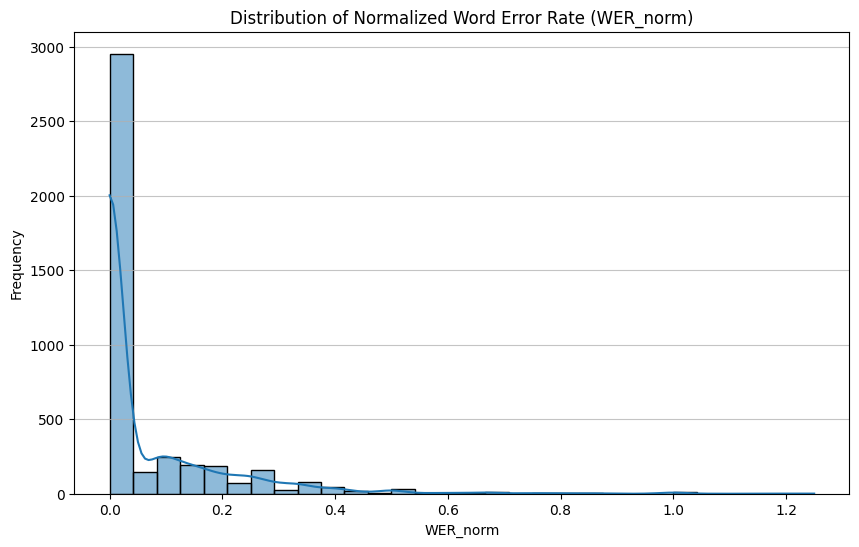

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(merged['wer_norm'], bins=30, kde=True)
plt.title('Distribution of Normalized Word Error Rate (WER_norm)')
plt.xlabel('WER_norm')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [69]:
# macro-average: mean of each clip's own WER, grouped by accent
macro_wer = merged.groupby("primary_accent")["wer_norm"].agg(["mean", "std", "count"])
macro_wer = macro_wer.sort_values("mean")
print("Macro-average WER by accent:")
print(macro_wer)

# micro-average: pooling all errors and all words within each accent group, then divide once
def micro_wer(group):
    return jiwer.wer(
        list(group["sentence"]), list(group["asr_transcript"]),
        reference_transform=transform, hypothesis_transform=transform
    )

micro_result = merged.groupby("primary_accent").apply(micro_wer, include_groups=False)

comparison = pd.DataFrame({
    "macro_avg_wer": macro_wer["mean"],
    "micro_corpus_wer": micro_result
}).sort_values("micro_corpus_wer")

print("\nMacro vs micro WER by accent:")
print(comparison.round(4))

Macro-average WER by accent:
                                                        mean       std  count
primary_accent                                                               
United States English                               0.042909  0.102313    600
England English                                     0.045671  0.099685    600
Southern African (South Africa, Zimbabwe, Namibia)  0.050982  0.104462    600
Filipino                                            0.064776  0.120361    600
Hong Kong English                                   0.075606  0.157448    600
Malaysian English                                   0.078939  0.135964    600
India and South Asia (India, Pakistan, Sri Lanka)   0.083556  0.167284    600

Macro vs micro WER by accent:
                                                    macro_avg_wer  \
primary_accent                                                      
United States English                                      0.0429   
England English                

In [70]:
# Building a single, well-formatted comparison table: macro vs micro WER by accent
macro_wer = merged.groupby("primary_accent")["wer_norm"].agg(["mean", "std", "count"])

def micro_wer(group):
    return jiwer.wer(
        list(group["sentence"]), list(group["asr_transcript"]),
        reference_transform=transform, hypothesis_transform=transform
    )
micro_result = merged.groupby("primary_accent").apply(micro_wer, include_groups=False)

wer_table = pd.DataFrame({
    "n_clips": macro_wer["count"],
    "macro_avg_wer": macro_wer["mean"].round(4),
    "std": macro_wer["std"].round(4),
    "micro_corpus_wer": micro_result.round(4),
})
wer_table = wer_table.sort_values("micro_corpus_wer")
wer_table.insert(0, "rank", range(1, len(wer_table) + 1))

wer_table

,rank,n_clips,macro_avg_wer,std,micro_corpus_wer
primary_accent,,,,,
United States English,1,600,0.0429,0.1023,0.0427
England English,2,600,0.0457,0.0997,0.0451
"Southern African (South Africa, Zimbabwe, Namibia)",3,600,0.0510,0.1045,0.0492
Filipino,4,600,0.0648,0.1204,0.0625
Hong Kong English,5,600,0.0756,0.1574,0.0685
"India and South Asia (India, Pakistan, Sri Lanka)",6,600,0.0836,0.1673,0.0753
Malaysian English,7,600,0.0789,0.1360,0.0756


In [71]:
print(wer_table.to_markdown())

| primary_accent                                     |   rank |   n_clips |   macro_avg_wer |    std |   micro_corpus_wer |
|:---------------------------------------------------|-------:|----------:|----------------:|-------:|-------------------:|
| United States English                              |      1 |       600 |          0.0429 | 0.1023 |             0.0427 |
| England English                                    |      2 |       600 |          0.0457 | 0.0997 |             0.0451 |
| Southern African (South Africa, Zimbabwe, Namibia) |      3 |       600 |          0.051  | 0.1045 |             0.0492 |
| Filipino                                           |      4 |       600 |          0.0648 | 0.1204 |             0.0625 |
| Hong Kong English                                  |      5 |       600 |          0.0756 | 0.1574 |             0.0685 |
| India and South Asia (India, Pakistan, Sri Lanka)  |      6 |       600 |          0.0836 | 0.1673 |             0.0753 |
| Malays

| primary_accent                                     |   rank |   n_clips |   macro_avg_wer |    std |   micro_corpus_wer |
|:---------------------------------------------------|-------:|----------:|----------------:|-------:|-------------------:|
| United States English                              |      1 |       600 |          0.0429 | 0.1023 |             0.0427 |
| England English                                    |      2 |       600 |          0.0457 | 0.0997 |             0.0451 |
| Southern African (South Africa, Zimbabwe, Namibia) |      3 |       600 |          0.051  | 0.1045 |             0.0492 |
| Filipino                                           |      4 |       600 |          0.0648 | 0.1204 |             0.0625 |
| Hong Kong English                                  |      5 |       600 |          0.0756 | 0.1574 |             0.0685 |
| India and South Asia (India, Pakistan, Sri Lanka)  |      6 |       600 |          0.0836 | 0.1673 |             0.0753 |
| Malaysian English                                  |      7 |       600 |          0.0789 | 0.136  |             0.0756 |


I computed WER for all 4,200 clips and grouped by accent. United States English came out at 0.0427 and England English at 0.0451, both under 5% word error.

India and South Asia came out at 0.0753. Malaysian English came out at 0.0756. I'm treating these as tied rather than ranking one above the other, since a 0.0003 gap doesn't support a claim that one accent group transcribes worse than the other.

I also checked std alongside the mean. India and South Asia sits at 0.1673, Hong Kong English at 0.1574, both well above the ~0.10 I got for US and England English. A high std next to a high mean means the average WER isn't representative of most clips in that group. Some clips transcribed almost perfectly, others badly missed, and the mean flattens that into one number.

This table only covers WER, which only covers the ASR half of the Cascade pipeline. It tells me where transcription struggles concentrate by accent. It doesn't tell me anything about translation quality yet, and it can't say anything about Direct ST, since there's no transcript stage for Direct to fail at. Whether this same accent pattern shows up in chrF++ or BLEU is what I'm checking next, and the paired comparison in Section V-E is where I'll actually test it statistically rather than eyeball it.



## BLEU — plan before running the code

I'm computing BLEU for both Direct and Cascade translations against the Chinese
reference, then comparing them head to head. Before running anything, I want
to write down why tokenization needs a decision made up front, since it
changes the score by two orders of magnitude on this exact dataset.

**Papineni et al. 2002 [23]** is the paper that defines BLEU. It builds on
n-gram precision, counts overlapping n-grams between hypothesis and reference,
caps repeated-word credit with modified precision, and applies a brevity
penalty for short outputs. Nowhere does the paper specify how to split a
sentence into words for a non-whitespace language like Chinese. The paper was
built and evaluated on Chinese-to-English, where the output side is English
and tokenization is trivial.

**Post 2018 [27]** is the paper my own V.D draft already cites for a related
point: BLEU scores vary by up to 1.8 points, averaging around 1.0, purely from
differences in how references get tokenized or normalized before scoring.
Post's paper is about reporting BLEU consistently. It assumes tokenization
choice matters enough to break comparability between papers. I'm about to see
a version of that same problem, except much larger, because my target
language has no whitespace at all.

**The tokenization issue.** BLEU counts matching word n-grams. To do that it
first splits each sentence into words. English splits on spaces. Chinese
doesn't mark word boundaries with spaces at all — 我们谈到了马戏团的副表演 is
one continuous string of characters. A tokenizer built for whitespace
languages treats that entire sentence as a single unsplittable token. Compared
against a reference that becomes a different single unsplittable token, n-gram
overlap comes out at zero, regardless of how good the translation actually is.

**Comparison — default tokenizer vs Chinese-specific tokenizer, same sentence pair**

| | reference | hypothesis (Direct) | BLEU, default (13a) | BLEU, zh tokenizer |
|---|---|---|---|---|
| sample_0001 | 我们谈到了马戏团的杂耍表演。 | 我们谈到了马戏团的副表演. | 0.0 | 64.97 |

Across the first 20 clips, 20 out of 20 scored exactly 0.0 under the default
tokenizer. At corpus level across all 4,200 clips, Direct's BLEU comes out at
0.43 under the default tokenizer and 38.86 under the zh tokenizer.

I'm using `tokenize="zh"` from here on for every BLEU calculation on the
Chinese output. The default tokenizer isn't measuring translation quality on
this dataset. It's measuring its own inability to find a word boundary.

In [72]:
!pip install sacrebleu -q

import sacrebleu

def get_bleu_direct(row):
    return sacrebleu.sentence_bleu(
        row["direct_translation"], [row["reference_translation_zh"]], tokenize="zh"
    ).score

def get_bleu_cascade(row):
    return sacrebleu.sentence_bleu(
        row["cascade_translation"], [row["reference_translation_zh"]], tokenize="zh"
    ).score

merged["bleu_direct"] = merged.apply(get_bleu_direct, axis=1)
merged["bleu_cascade"] = merged.apply(get_bleu_cascade, axis=1)

refs = [merged["reference_translation_zh"].tolist()]
corpus_bleu_direct = sacrebleu.corpus_bleu(merged["direct_translation"].tolist(), refs, tokenize="zh")
corpus_bleu_cascade = sacrebleu.corpus_bleu(merged["cascade_translation"].tolist(), refs, tokenize="zh")

print("Corpus BLEU - Direct: ", round(corpus_bleu_direct.score, 2))
print("Corpus BLEU - Cascade:", round(corpus_bleu_cascade.score, 2))

Corpus BLEU - Direct:  38.86
Corpus BLEU - Cascade: 29.11


In [73]:
import sacrebleu

def get_bleu_direct(row):
    return sacrebleu.sentence_bleu(
        row["direct_translation"], [row["reference_translation_zh"]], tokenize="zh"
    ).score

def get_bleu_cascade(row):
    return sacrebleu.sentence_bleu(
        row["cascade_translation"], [row["reference_translation_zh"]], tokenize="zh"
    ).score

merged["bleu_direct"] = merged.apply(get_bleu_direct, axis=1)
merged["bleu_cascade"] = merged.apply(get_bleu_cascade, axis=1)

# macro: mean of per-clip BLEU scores, within each accent
macro_direct = merged.groupby("primary_accent")["bleu_direct"].mean()
macro_cascade = merged.groupby("primary_accent")["bleu_cascade"].mean()

# micro: proper corpus BLEU, pooled n-gram stats, computed once per accent group
def corpus_bleu_direct_group(group):
    return sacrebleu.corpus_bleu(
        group["direct_translation"].tolist(), [group["reference_translation_zh"].tolist()], tokenize="zh"
    ).score

def corpus_bleu_cascade_group(group):
    return sacrebleu.corpus_bleu(
        group["cascade_translation"].tolist(), [group["reference_translation_zh"].tolist()], tokenize="zh"
    ).score

micro_direct = merged.groupby("primary_accent").apply(corpus_bleu_direct_group, include_groups=False)
micro_cascade = merged.groupby("primary_accent").apply(corpus_bleu_cascade_group, include_groups=False)

bleu_table = pd.DataFrame({
    "macro_direct": macro_direct.round(2),
    "micro_direct": micro_direct.round(2),
    "macro_cascade": macro_cascade.round(2),
    "micro_cascade": micro_cascade.round(2),
})
bleu_table["gap_micro"] = (bleu_table["micro_direct"] - bleu_table["micro_cascade"]).round(2)
bleu_table = bleu_table.sort_values("micro_direct", ascending=False)

bleu_table

,macro_direct,micro_direct,macro_cascade,micro_cascade,gap_micro
primary_accent,,,,,
Filipino,37.13,40.68,27.98,30.03,10.65
Hong Kong English,36.36,39.23,26.66,28.09,11.14
Malaysian English,36.00,38.95,26.38,27.49,11.46
England English,35.94,38.51,29.31,30.82,7.69
"Southern African (South Africa, Zimbabwe, Namibia)",35.58,38.47,28.65,30.25,8.22
United States English,34.92,38.27,27.18,28.99,9.28
"India and South Asia (India, Pakistan, Sri Lanka)",35.34,37.55,25.83,27.78,9.77


## BLEU by accent group — explanation

I computed BLEU for every accent group two ways, macro and micro, for both
Direct and Cascade, using `tokenize="zh"` throughout for the reasons covered
in the tokenization section above.

| primary_accent                                     | macro_direct | micro_direct | macro_cascade | micro_cascade | gap_micro |
|:------------------------------------------------------|-------------:|-------------:|---------------:|---------------:|-----------:|
| Filipino                                               |        37.13 |        40.68 |           27.98 |           30.03 |      10.65 |
| Hong Kong English                                      |        36.36 |        39.23 |           26.66 |           28.09 |      11.14 |
| Malaysian English                                      |        36.00 |        38.95 |           26.38 |           27.49 |      11.46 |
| England English                                        |        35.94 |        38.51 |           29.31 |           30.82 |       7.69 |
| Southern African (South Africa, Zimbabwe, Namibia)     |        35.58 |        38.47 |           28.65 |           30.25 |       8.22 |
| United States English                                  |        34.92 |        38.27 |           27.18 |           28.99 |       9.28 |
| India and South Asia (India, Pakistan, Sri Lanka)      |        35.34 |        37.55 |           25.83 |           27.78 |       9.77 |

**Direct beats Cascade on every accent group, by 7.69 to 11.46 BLEU points.**
For context, Post 2018 [27] reports BLEU can vary by up to 1.8 points and
around 1.0 on average from tokenization and normalization choices alone, with
no change to the underlying system. My smallest gap (7.69, England English) is
already four times that noise floor. IWSLT 2021 findings [6], cited in my own
V.D draft, report a 2 BLEU gap between cascaded and direct systems in one
reference set and 0.7 in another. My gaps run three to five times larger than
that. I'm reading this as a real, system-level effect rather than something
tokenization variance or reference-set choice could produce on its own.

**The WER ranking and the Direct BLEU ranking do not line up.** United States
English has the lowest WER of the seven groups and one of the lowest Direct
BLEU scores. Filipino sits mid-table on WER and has the highest Direct BLEU.
Papineni et al. 2002 [23] built BLEU on top of WER specifically because WER
compares against one reference transcript and cannot capture word choice or
reordering, which is exactly the gap this table shows in practice.

**gap_micro itself is not a finding yet.** Malaysian English shows the widest
Direct-Cascade gap (11.46), England English the narrowest (7.69). Whether that
7.69-to-11.46 spread reflects a real accent effect or falls inside normal
variation across 600 clips is a question this table cannot answer on its own.
Koehn 2004 [24] shows that BLEU computed on different subsets of the same
corpus can vary substantially even with nothing changed about the systems
being compared, which is the reason a paired bootstrap comes before any claim
about accent-specific gap size, in Section V-E.

## Investigating the BLEU gap between Direct and Cascade

I checked the merge between the two run files before computing anything. `id`,
`path`, `sentence_id`, `sentence`, and `reference_translation_zh` all agree
row-for-row between direct_predictions.csv and cascade_predictions.csv, so
`id` is a safe merge key and both systems are scored against the same
reference sentences.

WER came out at 0.1056 raw and 0.0597 normalized (lowercase, punctuation
stripped). Raw WER was overstating error by close to half, almost entirely
from formatting differences like "Mr" vs "Mr." rather than real transcription
mistakes, so I'm using normalized WER from here on. BLEU needed the same kind
of check. The default tokenizer gave 0.0 on every Chinese sentence I tested,
because it splits on whitespace and Chinese doesn't use whitespace between
words, so the whole sentence becomes one unsplittable token and nothing can
match. Switching to `tokenize="zh"` fixed this and gave a corpus BLEU of 38.86
for Direct and 29.11 for Cascade, so that tokenizer is what I'm using for
every BLEU number from here on.

That 38.86 vs 29.11 gap looked large enough that I wanted to rule out a bug
before treating it as a real finding. Both systems compare against the same
reference column, pulled from the same merged row. Neither system has any
empty translations. That ruled out the two most obvious ways a scoring bug
could fake a gap this size. Then I looked at sacrebleu's full breakdown, not
just the single BLEU number. Direct: precision 63.2/45.2/32.7/24.3, brevity
penalty 1.000, output length ratio 1.006. Cascade: precision
59.7/39.0/25.8/17.7, brevity penalty 0.906, output length ratio 0.910.
Cascade's precision is lower starting from single words, and the gap widens
at every n-gram order up to 4-grams. Its output also runs about 9% shorter
than the reference on average, which triggers the brevity penalty and costs
it more points on top of the precision loss. Direct's output length matches
the reference closely enough to take no penalty at all.

Separately, 508 of the 4,200 Direct rows, about 12%, contain a literal `<unk>`
token inside the Chinese output text. BLEU on those 508 rows is 25.64, against
40.67 on the clean rows. Cascade has zero `<unk>` tokens anywhere in its
output. Checking a handful by hand, the pattern looks like proper names and
less common words with no vocabulary entry in the model, not a general
translation failure. sample_0002 is a clear case: Direct fails on "Jones"
with `<unk>`, but Cascade translates it correctly as 乔恩斯 in the exact same
spot. I sent the 508 affected rows, with both translations side by side, to
the teammate who ran the Direct pipeline, asking about beam size, max length,
and any vocab or tokenizer settings that might explain it, and whether this
is fixable with a rerun or a real limitation of the model.

So the size of the Direct-Cascade gap has more than one cause. Shorter
Cascade output, lower Cascade precision at every n-gram size, and a specific
vocabulary-coverage issue on Direct's side that Cascade doesn't share at all.

Grouping by accent, Direct beats Cascade on every single group, by 7.69 BLEU
(England English) to 11.46 BLEU (Malaysian English). I'm not treating that
spread as a finding yet, since 600 clips per group leaves room for it to be
sampling noise rather than a real accent effect, and that's exactly what the
paired bootstrap is for. The WER-by-accent ranking and the BLEU-by-accent
ranking don't line up either, aside from both ranking India and South Asia
lowest. United States English has the lowest WER of all seven accents and one
of the lowest Direct BLEU scores, which matches something already in my V.D
draft: WER doesn't show how much translation quality is lost, since errors of
similar size can produce very different amounts of translation damage.

Still to check: whether Cascade still loses to Direct on the subset of clips
where WER is exactly 0, which would separate a pure translation-quality gap
from ASR-error propagation. Whether `<unk>` rate varies by accent, which
would tie the vocabulary-coverage issue directly to the accent-robustness
question rather than leaving it as a general Direct weakness. How often
Cascade recovers specifically where Direct hits an `<unk>`, across all 508
rows rather than just the few I checked by hand. chrF++, not started yet,
which will need the same tokenization caution as BLEU, plus a decision
between plain chrF and chrF++ for Chinese, since Popović's chrF++ paper only
submitted plain chrF for Chinese and called the concept of a Chinese word
unclear. And after that, the paired bootstrap and the Spearman correlation
between WER and translation-quality degradation, which is what Section V-E
actually needs before any of the accent-level gaps above can be called a
real finding rather than a pattern in one table.

## Plan for chrF and chrF++

The goal is one table: accent group, WER, Direct chrF, Cascade chrF, the gap
between them, Direct chrF++, Cascade chrF++, and that gap too. Seven rows,
one per accent group, WER already computed.

chrF and chrF++ both come from sacrebleu's `CHRF` class. The two differ by one
setting. `word_order=0` gives plain chrF, character n-grams only, following
Popović 2015 [25]. `word_order=2` adds word unigrams and bigrams on top of the
character n-grams, which is what chrF++ means, following Popović 2017 [26].
I already confirmed this on one sentence earlier: chrF gave 60.23, chrF++ gave
51.62, same sentence pair, so the word component pulls the score down when
word-level matches are harder to find than character-level ones.

There's a decision to make before running anything at scale. Popović 2017
only submitted plain chrF for Chinese in her own paper, because the concept of
a Chinese word is not clearly defined, the same issue I already ran into with
BLEU's tokenizer. chrF++'s word-unigram and word-bigram component depends on
knowing where one Chinese word ends and the next begins, and that's exactly
the part Popović chose not to compute for Chinese at all. I'm running chrF++
anyway, since the project brief already names it as a primary metric, but I
need to check what word segmentation sacrebleu actually applies for Chinese
before trusting the number, the same way I had to check BLEU's tokenizer
before trusting that one.

There's also a beta setting to decide. Popović 2015 found beta=3 correlated
better with human judgment than beta=1 for plain chrF, though she called that
value preliminary rather than settled. Popović 2017 confirmed beta=2 as
optimal for chrF++, tested on English and Russian. sacrebleu's own default is
beta=2 regardless of which chrF variant you're running. I'll test both
defaults and the paper-recommended values before picking one, since a beta
mismatch here would be the same kind of silent scoring problem the tokenizer
was for BLEU.

Once the per-clip and per-accent numbers are stable, I'll compute macro and
micro versions the same way I did for WER and BLEU, and check whether they
disagree in a way that changes which accent looks worst, the same check that
flipped the ranking between Malaysian English and India and South Asia under
WER.

In [74]:
import sacrebleu

# Two metric objects, one per variant. The only difference is word_order.
# word_order=0 -> plain chrF (character n-grams only), Popovic 2015
# word_order=2 -> chrF++ (adds word unigrams and bigrams), Popovic 2017
chrf_metric = sacrebleu.metrics.CHRF(word_order=0, beta=2)
chrfpp_metric = sacrebleu.metrics.CHRF(word_order=2, beta=2)

def corpus_chrf_direct(group):
    return chrf_metric.corpus_score(
        group["direct_translation"].tolist(), [group["reference_translation_zh"].tolist()]
    ).score

def corpus_chrf_cascade(group):
    return chrf_metric.corpus_score(
        group["cascade_translation"].tolist(), [group["reference_translation_zh"].tolist()]
    ).score

def corpus_chrfpp_direct(group):
    return chrfpp_metric.corpus_score(
        group["direct_translation"].tolist(), [group["reference_translation_zh"].tolist()]
    ).score

def corpus_chrfpp_cascade(group):
    return chrfpp_metric.corpus_score(
        group["cascade_translation"].tolist(), [group["reference_translation_zh"].tolist()]
    ).score

g = merged.groupby("primary_accent")

chrf_table = pd.DataFrame({
    "WER": g["wer_norm"].mean().round(4),
    "chrF_direct": g.apply(corpus_chrf_direct, include_groups=False).round(2),
    "chrF_cascade": g.apply(corpus_chrf_cascade, include_groups=False).round(2),
    "chrFpp_direct": g.apply(corpus_chrfpp_direct, include_groups=False).round(2),
    "chrFpp_cascade": g.apply(corpus_chrfpp_cascade, include_groups=False).round(2),
})

chrf_table["chrF_gap"] = (chrf_table["chrF_direct"] - chrf_table["chrF_cascade"]).round(2)
chrf_table["chrFpp_gap"] = (chrf_table["chrFpp_direct"] - chrf_table["chrFpp_cascade"]).round(2)

chrf_table = chrf_table[["WER", "chrF_direct", "chrF_cascade", "chrF_gap",
                          "chrFpp_direct", "chrFpp_cascade", "chrFpp_gap"]]
chrf_table = chrf_table.sort_values("chrF_direct", ascending=False)

chrf_table

,WER,chrF_direct,chrF_cascade,chrF_gap,chrFpp_direct,chrFpp_cascade,chrFpp_gap
primary_accent,,,,,,,
Filipino,0.0648,33.92,24.83,9.09,26.09,18.80,7.29
Hong Kong English,0.0756,33.30,23.21,10.09,25.64,17.67,7.97
Malaysian English,0.0789,32.78,23.60,9.18,25.25,17.80,7.45
England English,0.0457,31.94,25.69,6.25,25.18,19.58,5.60
United States English,0.0429,31.74,24.04,7.70,24.86,18.22,6.64
"Southern African (South Africa, Zimbabwe, Namibia)",0.0510,31.66,24.96,6.70,24.54,19.10,5.44
"India and South Asia (India, Pakistan, Sri Lanka)",0.0836,31.40,23.08,8.32,24.11,17.75,6.36


## chrF and chrF++ by accent group

| primary_accent | WER | chrF_direct | chrF_cascade | chrF_gap | chrFpp_direct | chrFpp_cascade | chrFpp_gap |
|:---|---:|---:|---:|---:|---:|---:|---:|
| Filipino | 0.0648 | 33.92 | 24.83 | 9.09 | 26.09 | 18.80 | 7.29 |
| Hong Kong English | 0.0756 | 33.30 | 23.21 | 10.09 | 25.64 | 17.67 | 7.97 |
| Malaysian English | 0.0789 | 32.78 | 23.60 | 9.18 | 25.25 | 17.80 | 7.45 |
| England English | 0.0457 | 31.94 | 25.69 | 6.25 | 25.18 | 19.58 | 5.60 |
| United States English | 0.0429 | 31.74 | 24.04 | 7.70 | 24.86 | 18.22 | 6.64 |
| Southern African | 0.0510 | 31.66 | 24.96 | 6.70 | 24.54 | 19.10 | 5.44 |
| India and South Asia | 0.0836 | 31.40 | 23.08 | 8.32 | 24.11 | 17.75 | 6.36 |

Direct beats Cascade on every accent group under both metrics, same as BLEU
showed. The chrF gap runs 6.25 to 10.09. The chrF++ gap runs 5.44 to 7.97.

chrF++ scores lower than chrF on every single row, for both systems, by
roughly 6 to 8 points. This is the word component doing what Popović 2017 [26]
warned about for Chinese. Plain chrF only compares character n-grams, which
works on Chinese without needing to know where words begin and end. chrF++
adds word unigrams and bigrams on top, and finding word-level matches in
Chinese requires segmentation that the metric has to guess at. Fewer word
matches found means a lower score. The drop is consistent enough across all
seven groups and both systems that I'm reading it as a property of the metric
on Chinese rather than a real quality difference the metric is detecting.

The accent ranking barely changes between chrF and chrF++. Filipino is first
under both, India and South Asia is last under both, and the middle ordering
shifts only slightly. That consistency is useful. It means the choice between
chrF and chrF++ changes the absolute numbers but not which accents look
better or worse, so the ranking conclusion doesn't depend on which variant
I report.

The WER column still doesn't track the translation scores. United States
English has the lowest WER at 0.0429 and sits fifth on chrF_direct. Filipino
has mid-table WER at 0.0648 and tops both translation metrics. This is the
third metric to show the same disconnect, after BLEU, so it isn't an artifact
of how BLEU handles n-grams.

I used beta=2 for both variants, which is sacrebleu's default and the value
Popović 2017 confirmed as optimal for chrF++ on English and Russian. Popović
2015 preferred beta=3 for plain chrF, but called that value preliminary.
Testing beta=1, 2, and 3 on a single sentence moved chrF from 61.87 to 60.23
to 59.70, so the choice shifts scores by a point or two rather than changing
anything structural. Keeping beta=2 across both variants means the chrF and
chrF++ columns differ only by the word component, which is the comparison I
actually want.

## Why sacrebleu

I used sacrebleu for BLEU, chrF and chrF++ rather than NLTK or the Moses
scripts. The reason connects to a paper already in my reference list. Post
2018 [27] wrote about BLEU scores not being comparable across papers because
tokenization and preprocessing differences go unreported. sacrebleu is the
tool from that same paper, built to fix that problem. It applies a fixed,
documented tokenization scheme and reports a signature string describing
exactly what settings produced a score.

The alternatives all reintroduce the problem. NLTK's BLEU needs me to handle
tokenization myself, with no standard scheme and nothing to report. The Moses
multi-bleu script prints its own warning that scores depend on a tokenizer
unlikely to be reproducible across research groups, and a survey of 769 MT
papers found Moses-style aggressive tokenization produces BLEU scores several
points higher than sacrebleu on the same output. Popović's standalone
chrF++.py only handles chrF, so using it would mean two tools with two
different tokenization behaviours across my metrics.

For Chinese specifically, sacrebleu has a built-in zh tokenizer reachable
through one keyword argument. Older work had to run Chinese through a
separate external segmentation script before scoring. That's the difference
between one line of code and a preprocessing step I'd have to document and
defend separately.

I should record the sacrebleu signature strings alongside my scores, the way
current papers do, since that's the whole point of using it. Will add this as a future scope

## Future scope — correlation and paired bootstrap

Not implementing this yet. I want to sit with the theory longer before I write
any of it, since these two methods are the part of my section that actually
decides whether anything else in this notebook counts as a finding. Writing
the plan down now so the reasoning is recorded while it's fresh.

### What I already have that this depends on

Per-clip scores, one row per clip, all sitting in the same dataframe:
`wer_norm`, `bleu_direct`, `bleu_cascade`, and once I add them, per-clip chrF
and chrF++ for both systems. Everything below operates on per-clip numbers,
not the corpus-level ones, because both methods need to resample or rank
individual observations.

### Paired bootstrap

The goal is a confidence interval around the Direct-minus-Cascade gap, so I
can say whether the gap is real or whether it falls inside the range I'd
expect from sampling variation alone.

The steps, following Koehn 2004 [24]:

1. For every clip, compute one gap value: Direct score minus Cascade score.
   The pairing happens here. Each clip collapses to a single number before
   any resampling, so a resample never mixes one system's score from one clip
   with the other system's score from a different clip.
2. Draw a resample of n clips with replacement from those n gap values,
   where n is the number of clips in whatever group I'm testing.
3. Compute the mean gap for that resample. Store it.
4. Repeat 1000 times.
5. Sort the 1000 stored means. Drop the bottom 2.5% and the top 2.5%. What's
   left is the 95% confidence interval.
6. Decision rule: if the interval contains zero, I can't claim the gap is
   real. If it sits entirely above or below zero, the gap holds up.

I want to work through why resampling with replacement gives a valid interval
at all before I build it, since that's the step I understand least right now.
Once I've written my own version, I'll check it against sacrebleu's
`--paired-bs`, which implements the same paper and is result-compliant with
the reference Moses implementation. Matching numbers would tell me I've
understood it. A mismatch would tell me where my understanding breaks.

The independence assumption is the part I need to be honest about in the
write-up. Koehn's bootstrap assumes each clip is independent of the others.
My data breaks that. One speaker contributes many clips, and the same source
sentence appears more than once across the corpus. Resampling clips treats
those linked observations as separate, which makes the interval narrower than
it should be. Two things to check: how much clustering there actually is
(speakers with many clips, repeated sentences), and whether a speaker-level
bootstrap, resampling speakers rather than clips, widens the interval enough
to change any conclusion.

### Spearman correlation

The goal is to quantify something I've already seen by eye three times now,
across WER, BLEU and chrF: the WER ranking and the translation-quality
ranking don't line up.

I'm using Spearman rather than Pearson. Spearman works on ranks, so it
doesn't assume the relationship is a straight line, and a handful of clips
with extreme WER won't drag the coefficient around the way they would with
Pearson. Given how skewed the per-clip WER distribution looked, with std
larger than the mean in several accent groups, rank-based is the safer choice.
Before running it I want to be clearer on what a Spearman coefficient is
actually claiming, and what size of coefficient is worth reporting rather than
noting and moving past.

What to correlate, at the clip level:

- `wer_norm` against `bleu_cascade`. This is the direct question, since WER
  only exists for the Cascade path. A strong negative correlation would mean
  worse transcription reliably means worse translation.
- `wer_norm` against the per-clip gap (Direct minus Cascade). This asks
  something sharper: does Cascade fall further behind Direct specifically on
  the clips where ASR struggled? That's the error-propagation story stated as
  a testable claim.
- `wer_norm` against `bleu_direct`. This is the control. Direct has no ASR
  stage, so if WER correlates with Direct's score too, the correlation is
  probably picking up clip difficulty in general, not ASR error propagation.
  That comparison matters more than either number alone.

Run each of these overall and within each accent group, since a correlation
that holds corpus-wide might disappear or flip inside individual groups.

### Order I'll do it in

Per-clip chrF and chrF++ columns first, since I only have per-clip BLEU right
now. Then the WER = 0 subset check, which is a simpler version of the same
question the correlation asks and will tell me whether the correlation work
is worth doing at all. Then Spearman. Then the bootstrap.

## Extending the analysis to three systems
The analysis above established the Direct-vs-Cascade comparison using BLEU, chrF, chrF++, and WER. The next stage extends this comparison by adding a second Cascade system, Cascade-3.3B, alongside existing Cascade-600M system.

The purpose is twofold. First, Direct, Cascade-600M, and Cascade-3.3B can be compared using the same 4,200 clips and Chinese references. Second, because the 600M and 3.3B systems use identical ASR transcripts, their comparison isolates the effect of translation-model scale while holding the ASR input constant.

The following analysis therefore separates three questions: overall translation quality across the three systems, accent-level differences, and whether increasing the Cascade translation-model size improves performance when the ASR stage is unchanged.

In [75]:
# ============================================================
# 1. LOAD CASCADE-3.3B RESULTS
# ============================================================
#import pandas as pd
import numpy as np
#import sacrebleu

cascade_33b_url =  "https://raw.githubusercontent.com/Nlhmmh/cs760-accent-st-robustness-ml-research/main/runs/cascade_full_run_1790228071/cascade_predictions.csv"

cascade_33b =  pd.read_csv(cascade_33b_url)

print("Cascade - 3.3B shape:", cascade_33b.shape)

# Expected evaluation size
assert len(cascade_33b) == 4200

# Each clip should appear exactly once
assert cascade_33b["id"].is_unique

print("Cascade-3.3B validation passed")

Cascade - 3.3B shape: (4200, 24)
Cascade-3.3B validation passed


In [76]:
# ============================================================
# 2. VALIDATE 600M vs 3.3B PAIRING
#
# Important:
# The 600M and 3.3B Cascade systems must have:
#   - identical IDs
#   - identical source sentences
#   - identical accent labels
#   - identical Chinese references
#   - IDENTICAL ASR transcripts
#
# If ASR transcripts are identical, WER is identical.
# Therefore, any 600M -> 3.3B difference comes from the
# translation model rather than the ASR stage.
# ============================================================

c600 = cascade.sort_values("id").reset_index(drop=True)
c33b = cascade_33b.sort_values("id").reset_index(drop=True)

# same IDs
assert c600["id"].equals(c33b["id"])

# same source sentences
assert c600["sentence"].equals(c33b["sentence"])

# same accent labels
assert c600["primary_accent"].equals(c33b["primary_accent"])

# same Chinese reference
assert c600["reference_translation_zh"].equals(c33b["reference_translation_zh"])

# same ASR transcripts
asr_diff = c600["asr_transcript"] != (c33b["asr_transcript"])


print("ASR transcript differences:", asr_diff.sum())

assert asr_diff.sum() == 0, (
    "ERROR: 600M and 3.3B ASR transcripts are different")

print()
print("600M vs 3.3B are fully aligned.")
print("ASR transcripts are identical.")

ASR transcript differences: 0

600M vs 3.3B are fully aligned.
ASR transcripts are identical.


### Alignment check
The 600M and 3.3B Cascade runs are alined on all evaluation fields, including the source sentence, accent label, reference translation, and ASR transcript. No ASR transcript differs between the two runs.

This means the two Cascade systems provide a controlled comparison of translation-model scale: the ASR input is held constant while the translation model changes from 600M to 3.3B parameters.

In [77]:
# ============================================================
# 3. BUILD THREE-SYSTEM DATAFRAME
#
# One row = one clip.
#
# This becomes the main dataframe for the rest of the analysis.
# ============================================================
merged_3system = merged[
    [
    "id",
    "sample_id",
    "sentence",
    "primary_accent",
    "reference_translation_zh",

    # ASR/WER
    "asr_transcript",
    "wer_norm",

    # Translation outputs
    "direct_translation",
    "cascade_translation",

    ] ].copy()

# Rename 600M translation explicitly
merged_3system = merged_3system.rename(
    columns = {
        "cascade_translation": "cascade_600m_translation",
    }
)

# Add 3.3B translation
merged_3system = merged_3system.merge(
    cascade_33b[["id", "cascade_translation"]],
    on="id",
    how="inner"
)

# Rename 3.3B translation
merged_3system = merged_3system.rename(
    columns = {
        "cascade_translation": "cascade_33b_translation",
    }
)

# Final alignment check
assert len(merged_3system) == 4200
assert merged_3system["id"].is_unique

print("Three-system dataframe shape:", merged_3system.shape)
print("\nColumns:", merged_3system.columns.tolist())

Three-system dataframe shape: (4200, 10)

Columns: ['id', 'sample_id', 'sentence', 'primary_accent', 'reference_translation_zh', 'asr_transcript', 'wer_norm', 'direct_translation', 'cascade_600m_translation', 'cascade_33b_translation']


In [78]:
# ============================================================
# 4. T1 - CORPUS-LEVEL OVERALL METRICS
# This is the main overall comparison between the three systems.
#
# BLEU, chrF and chrF++ are calculated at CORPUS level:
# they are NOT averages of sentence-level scores.
#
# All three systems are evaluated against the same 4,200
# Chinese reference translations.
#
# WER is only applicable to the Cascade systems because Direct
# does not contain an ASR stage.
# ============================================================

refs = merged_3system["reference_translation_zh"].tolist()


# ------------------------------------------------------------
# Direct
# ------------------------------------------------------------
direct_hyp = merged_3system["direct_translation"].tolist()

direct_bleu = sacrebleu.corpus_bleu(
    direct_hyp,
    [refs],
    tokenize="zh"
).score

direct_chrf = chrf_metric.corpus_score(
    direct_hyp,
    [refs]
).score

direct_chrfpp = chrfpp_metric.corpus_score(
    direct_hyp,
    [refs]
).score

# ------------------------------------------------------------
# Cascade-600M
# ------------------------------------------------------------

cascade_600m_hyp = merged_3system[
    "cascade_600m_translation"
].tolist()

cascade_600m_bleu = sacrebleu.corpus_bleu(
    cascade_600m_hyp,
    [refs],
    tokenize="zh"
).score

cascade_600m_chrf = chrf_metric.corpus_score(
    cascade_600m_hyp,
    [refs]
).score

cascade_600m_chrfpp = chrfpp_metric.corpus_score(
    cascade_600m_hyp,
    [refs]
).score


# ------------------------------------------------------------
# Cascade-3.3B
# ------------------------------------------------------------
cascade_33b_hyp = merged_3system[
    "cascade_33b_translation"
].tolist()

cascade_33b_bleu = sacrebleu.corpus_bleu(
    cascade_33b_hyp,
    [refs],
    tokenize="zh"
).score

cascade_33b_chrf = chrf_metric.corpus_score(
    cascade_33b_hyp,
    [refs]
).score

cascade_33b_chrfpp = chrfpp_metric.corpus_score(
    cascade_33b_hyp,
    [refs]
).score


# ------------------------------------------------------------
# Build corpus-level table
# ------------------------------------------------------------

t1 = pd.DataFrame([
    {
        "System": "Direct",
        "N": len(merged_3system),
        "BLEU": direct_bleu,
        "chrF": direct_chrf,
        "chrF++": direct_chrfpp,
        "WER": np.nan,
    },

    {
        "System": "Cascade-600M",
        "N": len(merged_3system),
        "BLEU": cascade_600m_bleu,
        "chrF": cascade_600m_chrf,
        "chrF++": cascade_600m_chrfpp,
        "WER": merged_3system["wer_norm"].mean(),
    },

    {
        "System": "Cascade-3.3B",
        "N": len(merged_3system),
        "BLEU": cascade_33b_bleu,
        "chrF": cascade_33b_chrf,
        "chrF++": cascade_33b_chrfpp,
        "WER": merged_3system["wer_norm"].mean(),
    },
])

# Display version
t1_display = t1.copy()

t1_display[
    ["BLEU", "chrF", "chrF++"]
] = t1_display[
    ["BLEU", "chrF", "chrF++"]
].round(2)

t1_display["WER"] = t1_display["WER"].round(4)

print("Corpus-level translation metrics (4,200 clips)")
print(t1_display.to_markdown(index=False))

#t1_display


Corpus-level translation metrics (4,200 clips)
| System       |    N |   BLEU |   chrF |   chrF++ |      WER |
|:-------------|-----:|-------:|-------:|---------:|---------:|
| Direct       | 4200 |  38.86 |  32.38 |    25.08 | nan      |
| Cascade-600M | 4200 |  29.11 |  24.23 |    18.44 |   0.0632 |
| Cascade-3.3B | 4200 |  31.91 |  26.36 |    20.06 |   0.0632 |


In [79]:
# ============================================================
# 5. T1b - CORPUS-LEVEL PAIRWISE GAPS
#
# Positive value means the system named on the left has the
# higher score.
#
# The 3.3B - 600M comparison is especially important:
# because their ASR transcripts are identical, this isolates
# the effect of translation-model scaling.
# ============================================================

t1_indexed = t1.set_index("System")

gap_table = pd.DataFrame({
    "Metric": [
        "BLEU",
        "chrF",
        "chrF++"
    ],

    # Direct - Cascade-600M
    "(Direct - 600M)": [
        t1_indexed.loc["Direct", "BLEU"]
        - t1_indexed.loc["Cascade-600M", "BLEU"],

        t1_indexed.loc["Direct", "chrF"]
        - t1_indexed.loc["Cascade-600M", "chrF"],

        t1_indexed.loc["Direct", "chrF++"]
        - t1_indexed.loc["Cascade-600M", "chrF++"],
    ],

    # Direct - Cascade-3.3B
    "(Direct - 3.3B)": [
        t1_indexed.loc["Direct", "BLEU"]
        - t1_indexed.loc["Cascade-3.3B", "BLEU"],

        t1_indexed.loc["Direct", "chrF"]
        - t1_indexed.loc["Cascade-3.3B", "chrF"],

        t1_indexed.loc["Direct", "chrF++"]
        - t1_indexed.loc["Cascade-3.3B", "chrF++"],
    ],

    # 3.3B - 600M
    "(3.3B - 600M)": [
        t1_indexed.loc["Cascade-3.3B", "BLEU"]
        - t1_indexed.loc["Cascade-600M", "BLEU"],

        t1_indexed.loc["Cascade-3.3B", "chrF"]
        - t1_indexed.loc["Cascade-600M", "chrF"],

        t1_indexed.loc["Cascade-3.3B", "chrF++"]
        - t1_indexed.loc["Cascade-600M", "chrF++"],
    ],
})

gap_table.iloc[:, 1:] = gap_table.iloc[:, 1:].round(2)

print("\nCorpus-level pairwise metric gaps")
print(gap_table.to_markdown(index=False))

#gap_table


Corpus-level pairwise metric gaps
| Metric   |   (Direct - 600M) |   (Direct - 3.3B) |   (3.3B - 600M) |
|:---------|------------------:|------------------:|----------------:|
| BLEU     |              9.75 |              6.94 |            2.81 |
| chrF     |              8.15 |              6.01 |            2.14 |
| chrF++   |              6.64 |              5.03 |            1.62 |


In [80]:
# ============================================================
# 6. PER-CLIP chrF++
#
# These sentence-level scores are retained for later:
#   - paired bootstrap
#   - WER vs translation-quality correlation
#   - per-clip Direct/Cascade gaps
#
# IMPORTANT:
# These are NOT the corpus-level chrF++ scores from T1.
# ============================================================

sentence_chrfpp_metric = sacrebleu.metrics.CHRF(
    word_order=2, beta=2)

def sentence_chrfpp(hyp, ref):
  return sentence_chrfpp_metric.sentence_score(
      hyp,[ref]).score

merged_3system["chrfpp_direct"] = merged_3system.apply(
    lambda r: sentence_chrfpp(
        r["direct_translation"],
        r["reference_translation_zh"]),
    axis=1
)

merged_3system["chrfpp_600m"] = merged_3system.apply(
    lambda r: sentence_chrfpp(
        r["cascade_600m_translation"],
        r["reference_translation_zh"]),
    axis=1
)

merged_3system["chrfpp_33b"] = merged_3system.apply(
    lambda r: sentence_chrfpp(
        r["cascade_33b_translation"],
        r["reference_translation_zh"]),
    axis=1
)

# ------------------------------------------------------------
# Per-clip pairwise gaps
# ------------------------------------------------------------
merged_3system["gap_direct_600m"] = (
    merged_3system["chrfpp_direct"]
    - merged_3system["chrfpp_600m"])

merged_3system["gap_direct_33b"] = (
    merged_3system["chrfpp_direct"]
    - merged_3system["chrfpp_33b"])

merged_3system["gap_33b_600m"] = (
    merged_3system["chrfpp_33b"]
    - merged_3system["chrfpp_600m"])

print("Per-clip chrF++ columns added.")


Per-clip chrF++ columns added.


*Note:*

z8Per-clip chrF++ scores are used for paired comparisons and correlation analysis; corpus-level chrF++ is used for overall system evaluation.*

In [81]:
# ============================================================
# 7. T2 - CORPUS chrF++ BY ACCENT
#
# Each row is one accent group.
#
# These are MICRO / CORPUS-level chrF++ scores within each
# accent group, not means of the 600 sentence-level scores.
# ============================================================

def corpus_chrfpp_group(group, column):
    return chrfpp_metric.corpus_score(
        group[column].tolist(),
        [group["reference_translation_zh"].tolist()]
    ).score

t2 = []

for accent, group in merged_3system.groupby("primary_accent"):
    t2.append({
        "Accent": accent,
        "Direct": corpus_chrfpp_group(
            group, "direct_translation"),
        "Cascade-600M": corpus_chrfpp_group(
            group, "cascade_600m_translation"),
        "Cascade-3.3B": corpus_chrfpp_group(
            group, "cascade_33b_translation"),
    })

t2 = pd.DataFrame(t2)

t2 = t2.sort_values(
    "Cascade-3.3B", ascending=False
    ).reset_index(drop=True)

print("Corpus chrF++ by accent")
print(t2.round(2).to_markdown(index=False))

#t2.round(2)

Corpus chrF++ by accent
| Accent                                             |   Direct |   Cascade-600M |   Cascade-3.3B |
|:---------------------------------------------------|---------:|---------------:|---------------:|
| Filipino                                           |    26.09 |          18.8  |          21.68 |
| England English                                    |    25.18 |          19.58 |          20.42 |
| Southern African (South Africa, Zimbabwe, Namibia) |    24.54 |          19.1  |          20.37 |
| United States English                              |    24.86 |          18.22 |          19.83 |
| Malaysian English                                  |    25.25 |          17.8  |          19.62 |
| India and South Asia (India, Pakistan, Sri Lanka)  |    24.11 |          17.75 |          19.32 |
| Hong Kong English                                  |    25.64 |          17.67 |          18.87 |


In [82]:
# ============================================================
# 7b. BLEU BY ACCENT — THREE-SYSTEM COMPARISON
#
# Each row is one accent group.
#
# These are MICRO / CORPUS-level BLEU scores within each
# accent group, not means of the sentence-level BLEU scores.
# ============================================================

def corpus_bleu_group(group, column):
    return sacrebleu.corpus_bleu(
        group[column].tolist(),
        [group["reference_translation_zh"].tolist()],
        tokenize="zh"
    ).score


bleu_table_3system = []

for accent, group in merged_3system.groupby("primary_accent"):
    bleu_table_3system.append({
        "Accent": accent,
        "Direct": corpus_bleu_group(
            group,
            "direct_translation"
        ),
        "Cascade-600M": corpus_bleu_group(
            group,
            "cascade_600m_translation"
        ),
        "Cascade-3.3B": corpus_bleu_group(
            group,
            "cascade_33b_translation"
        ),
    })

bleu_table_3system = pd.DataFrame(
    bleu_table_3system
)

# ------------------------------------------------------------
# Pairwise BLEU gaps
# ------------------------------------------------------------

bleu_table_3system["Direct-600M"] = (
    bleu_table_3system["Direct"]
    - bleu_table_3system["Cascade-600M"]
).round(2)

bleu_table_3system["Direct-3.3B"] = (
    bleu_table_3system["Direct"]
    - bleu_table_3system["Cascade-3.3B"]
).round(2)

bleu_table_3system["3.3B-600M"] = (
    bleu_table_3system["Cascade-3.3B"]
    - bleu_table_3system["Cascade-600M"]
).round(2)

# Sort by Cascade-3.3B performance
bleu_table_3system = bleu_table_3system.sort_values(
    "Cascade-3.3B",
    ascending=False
)

print("Corpus BLEU by accent — three-system comparison")
print(
    bleu_table_3system
    .round(2)
    .to_markdown(index=False)
)

# Save table
bleu_table_3system.to_csv(
    "table_bleu_by_accent_three_systems.csv",
    index=False
)

Corpus BLEU by accent — three-system comparison
| Accent                                             |   Direct |   Cascade-600M |   Cascade-3.3B |   Direct-600M |   Direct-3.3B |   3.3B-600M |
|:---------------------------------------------------|---------:|---------------:|---------------:|--------------:|--------------:|------------:|
| Filipino                                           |    40.68 |          30.03 |          34.03 |         10.65 |          6.65 |        4    |
| Southern African (South Africa, Zimbabwe, Namibia) |    38.47 |          30.25 |          33.26 |          8.22 |          5.22 |        3    |
| England English                                    |    38.51 |          30.82 |          32.31 |          7.69 |          6.21 |        1.49 |
| United States English                              |    38.27 |          28.99 |          31.65 |          9.27 |          6.62 |        2.65 |
| Malaysian English                                  |    38.95 |          2

In [83]:
# ============================================================
# 8. MACRO vs MICRO chrF++ BY ACCENT
#
# MACRO:
#   Mean of the 600 sentence-level chrF++ scores.
#   Every clip gets equal weight.
#
# MICRO:
#   Micro/corpus chrF++ is calculated from
#   pooled corpus-level statistics within each accent group,
#   whereas macro chrF++ gives each clip equal weight
#   by averaging the sentence-level scores.
#
# Keeping both lets us check whether the ranking depends on
# how the metric is aggregated.
# ============================================================


# ------------------------------------------------------------
# Macro scores
# ------------------------------------------------------------
macro_direct = (
    merged_3system
    .groupby("primary_accent")["chrfpp_direct"]
    .mean()
)

macro_600m = (
    merged_3system
    .groupby("primary_accent")["chrfpp_600m"]
    .mean()
)

macro_33b = (
    merged_3system
    .groupby("primary_accent")["chrfpp_33b"]
    .mean()
)


# ------------------------------------------------------------
# Micro / corpus scores
# ------------------------------------------------------------
micro_direct = (
    merged_3system
    .groupby("primary_accent")
    .apply(
    lambda g: corpus_chrfpp_group(
        g, "direct_translation"
        ),
    include_groups=False
    )
)

micro_600m = (
    merged_3system
    .groupby("primary_accent")
    .apply(
    lambda g: corpus_chrfpp_group(
        g, "cascade_600m_translation"
        ),
    include_groups=False
    )
)

micro_33b = (
    merged_3system
    .groupby("primary_accent")
    .apply(
        lambda g: corpus_chrfpp_group(
            g,
            "cascade_33b_translation"
        ),
        include_groups=False
    )
)


# ------------------------------------------------------------
# Build table
# ------------------------------------------------------------
chrfpp_table = pd.DataFrame({
    "macro_direct": macro_direct.round(2),
    "micro_direct": micro_direct.round(2),

    "macro_600m": macro_600m.round(2),
    "micro_600m": micro_600m.round(2),

    "macro_33b": macro_33b.round(2),
    "micro_33b": micro_33b.round(2),
})


# ------------------------------------------------------------
# Pairwise micro gaps
# ------------------------------------------------------------
chrfpp_table["gap_micro_direct_600m"] = (
    chrfpp_table["micro_direct"] -
    chrfpp_table["micro_600m"]
).round(2)

chrfpp_table["gap_micro_direct_33b"] = (
    chrfpp_table["micro_direct"] -
    chrfpp_table["micro_33b"]
).round(2)

chrfpp_table["gap_micro_33b_600m"] = (
    chrfpp_table["micro_33b"] -
    chrfpp_table["micro_600m"]
).round(2)


# Sort by 3.3B performance
chrfpp_table = chrfpp_table.sort_values(
    "micro_33b",
    ascending=False
)

print("Macro vs micro chrF++ by accent")
print(chrfpp_table.to_markdown())

#chrfpp_table

Macro vs micro chrF++ by accent
| primary_accent                                     |   macro_direct |   micro_direct |   macro_600m |   micro_600m |   macro_33b |   micro_33b |   gap_micro_direct_600m |   gap_micro_direct_33b |   gap_micro_33b_600m |
|:---------------------------------------------------|---------------:|---------------:|-------------:|-------------:|------------:|------------:|------------------------:|-----------------------:|---------------------:|
| Filipino                                           |          28.9  |          26.09 |        21.23 |        18.8  |       24.48 |       21.68 |                    7.29 |                   4.41 |                 2.88 |
| England English                                    |          27.88 |          25.18 |        22.47 |        19.58 |       23.64 |       20.42 |                    5.6  |                   4.76 |                 0.84 |
| Southern African (South Africa, Zimbabwe, Namibia) |          27.2  |          24.

In [84]:
# ============================================================
# 9. T3 - PER-ACCENT chrF++ GAPS
#
# These are based on the per-clip chrF++ scores.
#
# Positive:
#   Direct > Cascade
#   or
#   3.3B > 600M
#
# These are descriptive gaps only.
# Statistical testing comes later with the paired bootstrap.
# ============================================================
t3 = merged_3system.groupby("primary_accent")[
    [
        "gap_direct_600m",
        "gap_direct_33b",
        "gap_33b_600m"
    ]
].mean().rename(columns={
    "gap_direct_600m": "Direct-600M",
    "gap_direct_33b": "Direct-3.3B",
    "gap_33b_600m": "3.3B-600M",
})

print("Mean per-clip chrF++ gaps by accent")
print(t3.round(2).to_markdown())

#t3.round(2)

Mean per-clip chrF++ gaps by accent
| primary_accent                                     |   Direct-600M |   Direct-3.3B |   3.3B-600M |
|:---------------------------------------------------|--------------:|--------------:|------------:|
| England English                                    |          5.41 |          4.24 |        1.17 |
| Filipino                                           |          7.68 |          4.42 |        3.25 |
| Hong Kong English                                  |          8.36 |          7.02 |        1.34 |
| India and South Asia (India, Pakistan, Sri Lanka)  |          7.63 |          5.41 |        2.22 |
| Malaysian English                                  |          7.86 |          5.66 |        2.2  |
| Southern African (South Africa, Zimbabwe, Namibia) |          5.52 |          3.5  |        2.02 |
| United States English                              |          6.57 |          4.66 |        1.91 |


In [85]:
# ============================================================
# 10. T4 - WER BY ACCENT
#
# WER is identical for Cascade-600M and Cascade-3.3B because
# their ASR transcripts were verified to be identical.
#
# Direct has no WER because it does not have an ASR stage.
# ============================================================
t4 = (
    merged_3system
    .groupby("primary_accent")["wer_norm"]
    .agg(
        WER="mean",
        WER_STD="std",
        N_clips="count"
        )
    )

print("WER by accent")
print(t4.round(4).to_markdown())

#t4.round(4)

WER by accent
| primary_accent                                     |    WER |   WER_STD |   N_clips |
|:---------------------------------------------------|-------:|----------:|----------:|
| England English                                    | 0.0457 |    0.0997 |       600 |
| Filipino                                           | 0.0648 |    0.1204 |       600 |
| Hong Kong English                                  | 0.0756 |    0.1574 |       600 |
| India and South Asia (India, Pakistan, Sri Lanka)  | 0.0836 |    0.1673 |       600 |
| Malaysian English                                  | 0.0789 |    0.136  |       600 |
| Southern African (South Africa, Zimbabwe, Namibia) | 0.051  |    0.1045 |       600 |
| United States English                              | 0.0429 |    0.1023 |       600 |


In [86]:
# ============================================================
# 11. T5 - DIRECT <unk> RATE BY ACCENT
#
# This measures how often the Direct system produces a literal
# <unk> token in its Chinese output.
# ============================================================
merged_3system["direct_has_unk"] = (
    merged_3system["direct_translation"]
    .str.contains("<unk>", regex=False, na=False)
)

t5 = (
    merged_3system
    .groupby("primary_accent")
    .agg(
        n_clips=("id", "count"),
        unk_clips=("direct_has_unk", "sum")
    )
)

t5["unk_rate"] = (
    t5["unk_clips"]
    / t5["n_clips"]
)

t5["unk_rate_pct"] = (
    100 * t5["unk_rate"]
)

print("Direct <unk> rate by accent")
print(t5.round(4).to_markdown())

#t5.round(4)

Direct <unk> rate by accent
| primary_accent                                     |   n_clips |   unk_clips |   unk_rate |   unk_rate_pct |
|:---------------------------------------------------|----------:|------------:|-----------:|---------------:|
| England English                                    |       600 |          81 |     0.135  |        13.5    |
| Filipino                                           |       600 |          65 |     0.1083 |        10.8333 |
| Hong Kong English                                  |       600 |          62 |     0.1033 |        10.3333 |
| India and South Asia (India, Pakistan, Sri Lanka)  |       600 |          80 |     0.1333 |        13.3333 |
| Malaysian English                                  |       600 |          78 |     0.13   |        13      |
| Southern African (South Africa, Zimbabwe, Namibia) |       600 |          66 |     0.11   |        11      |
| United States English                              |       600 |          76 |    

In [87]:
# ============================================================
# 12. DIRECT <unk> DIAGNOSTIC
#
# Compare Direct translation quality:
#
#   A. all 4,200 clips
#   B. only clips without <unk>
#
# This tells us how much the <unk> problem contributes to the
# overall Direct score.
# ============================================================

direct_clean_mask = (
    ~merged_3system["direct_has_unk"]
)


def score_direct_subset(mask):

    subset = merged_3system.loc[mask]

    hypotheses = (
        subset["direct_translation"]
        .tolist()
    )

    references = [
        subset["reference_translation_zh"]
        .tolist()
    ]

    return {
        "N": len(subset),

        "BLEU": sacrebleu.corpus_bleu(
            hypotheses,
            references,
            tokenize="zh"
        ).score,

        "chrF": chrf_metric.corpus_score(
            hypotheses,
            references
        ).score,

        "chrF++": chrfpp_metric.corpus_score(
            hypotheses,
            references
        ).score,
    }


# All 4,200 clips
direct_all_scores = score_direct_subset(
    pd.Series(
        True,
        index=merged_3system.index
    )
)

# <unk>-free clips
direct_clean_scores = score_direct_subset(
    direct_clean_mask
)


unk_comparison = pd.DataFrame([
    {
        "Subset": "All clips",
        **direct_all_scores
    },
    {
        "Subset": "<unk>-free clips",
        **direct_clean_scores
    }
])


print("Direct: all clips vs <unk>-free clips")
print(
    unk_comparison.round(2)
    .to_markdown(index=False)
)

#unk_comparison

Direct: all clips vs <unk>-free clips
| Subset           |    N |   BLEU |   chrF |   chrF++ |
|:-----------------|-----:|-------:|-------:|---------:|
| All clips        | 4200 |  38.86 |  32.38 |    25.08 |
| <unk>-free clips | 3692 |  40.67 |  33.91 |    26.32 |


In [88]:
# ============================================================
# 13. FINAL CHECK + SAVE ANALYSIS DATAFRAME
#
# This preserves all per-clip metrics for the next stage:
#   - WER = 0 analysis
#   - Spearman correlation
#   - paired bootstrap
# ============================================================

# Final sanity checks
assert len(merged_3system) == 4200
assert merged_3system["id"].is_unique

required_columns = [
    "id",
    "primary_accent",
    "wer_norm",
    "chrfpp_direct",
    "chrfpp_600m",
    "chrfpp_33b",
    "gap_direct_600m",
    "gap_direct_33b",
    "gap_33b_600m",
]

assert all(
    col in merged_3system.columns
    for col in required_columns
)

print("Final validation passed.")
print("Rows:", len(merged_3system))
print("Unique IDs:", merged_3system["id"].nunique())

# Save
merged_3system.to_csv(
    "merged_3system_with_metrics.csv",
    index=False
)

print("Saved: merged_3system_with_metrics.csv")

# For reproducibility:
t1.to_csv(
    "table_T1_corpus_metrics.csv", index=False)
gap_table.to_csv(
    "table_T1b_pairwise_gaps.csv", index=False)
t2.to_csv(
    "table_T2_chrfpp_by_accent.csv", index=False)
chrfpp_table.to_csv(
    "table_macro_micro_chrfpp.csv")
t3.to_csv(
    "table_T3_chrfpp_gaps.csv")
t4.to_csv(
    "table_T4_wer_by_accent.csv")
t5.to_csv(
    "table_T5_direct_unk_by_accent.csv")
unk_comparison.to_csv(
    "table_direct_unk_comparison.csv", index=False)

Final validation passed.
Rows: 4200
Unique IDs: 4200
Saved: merged_3system_with_metrics.csv


In [89]:
!git clone https://github.com/Nlhmmh/cs760-accent-st-robustness-ml-research.git
%cd cs760-accent-st-robustness-ml-research

Cloning into 'cs760-accent-st-robustness-ml-research'...
remote: Enumerating objects: 302, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 302 (delta 0), reused 0 (delta 0), pack-reused 272 (from 1)
Receiving objects: 100% (302/302), 21.76 MiB | 18.48 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/cs760-accent-st-robustness-ml-research


In [90]:
!git status
!ls

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
9_Proposal.pdf	   README.md
literature_review  README-running-pipelines.md
notebooks	   runs
presentation	   SeamlessM4T_UNK_Investigation_Log.md


In [ ]:
from google.colab import _message
import json

response = _message.blocking_request(
    'get_ipynb',
    timeout_sec=30
)

# Colab returns the notebook inside an "ipynb" response field.
# Save the notebook itself so Jupyter and Colab can open the file.
notebook = response.get('ipynb', response)

with open('/content/08_evaluation.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)
    f.write('\n')
